# Circumplex Validation

Validate Russell's Circumplex Model results for Reddit mental health posts.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from emotion_circumplex_mapping import EMOTION_MAPPING

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

# Detect environment
if os.path.exists('/content/drive'):
    BASE_DIR = Path("/content/drive/MyDrive/mental_health_research_V2")
else:
    BASE_DIR = Path.cwd()

RESULTS_DIR = BASE_DIR / "results" / "reddit_inference"
VIZ_DIR = RESULTS_DIR / "visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results: {RESULTS_DIR}")
print(f"Visualizations: {VIZ_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results: /content/drive/MyDrive/mental_health_research_V2/results/reddit_inference
Visualizations: /content/drive/MyDrive/mental_health_research_V2/results/reddit_inference/visualizations


In [3]:
# Load circumplex data
files = sorted(RESULTS_DIR.glob("reddit_with_circumplex_*.json"))

if not files:
    print(f"ERROR: No circumplex files in {RESULTS_DIR}")
    raise FileNotFoundError("Run Add_Circumplex_Features.ipynb first")

input_file = files[-1]
print(f"Loading: {input_file.name}")

df = pd.read_json(input_file)
print(f"Loaded {len(df):,} posts")

Loading: reddit_with_circumplex_20251120_192036.json
Loaded 40,745 posts


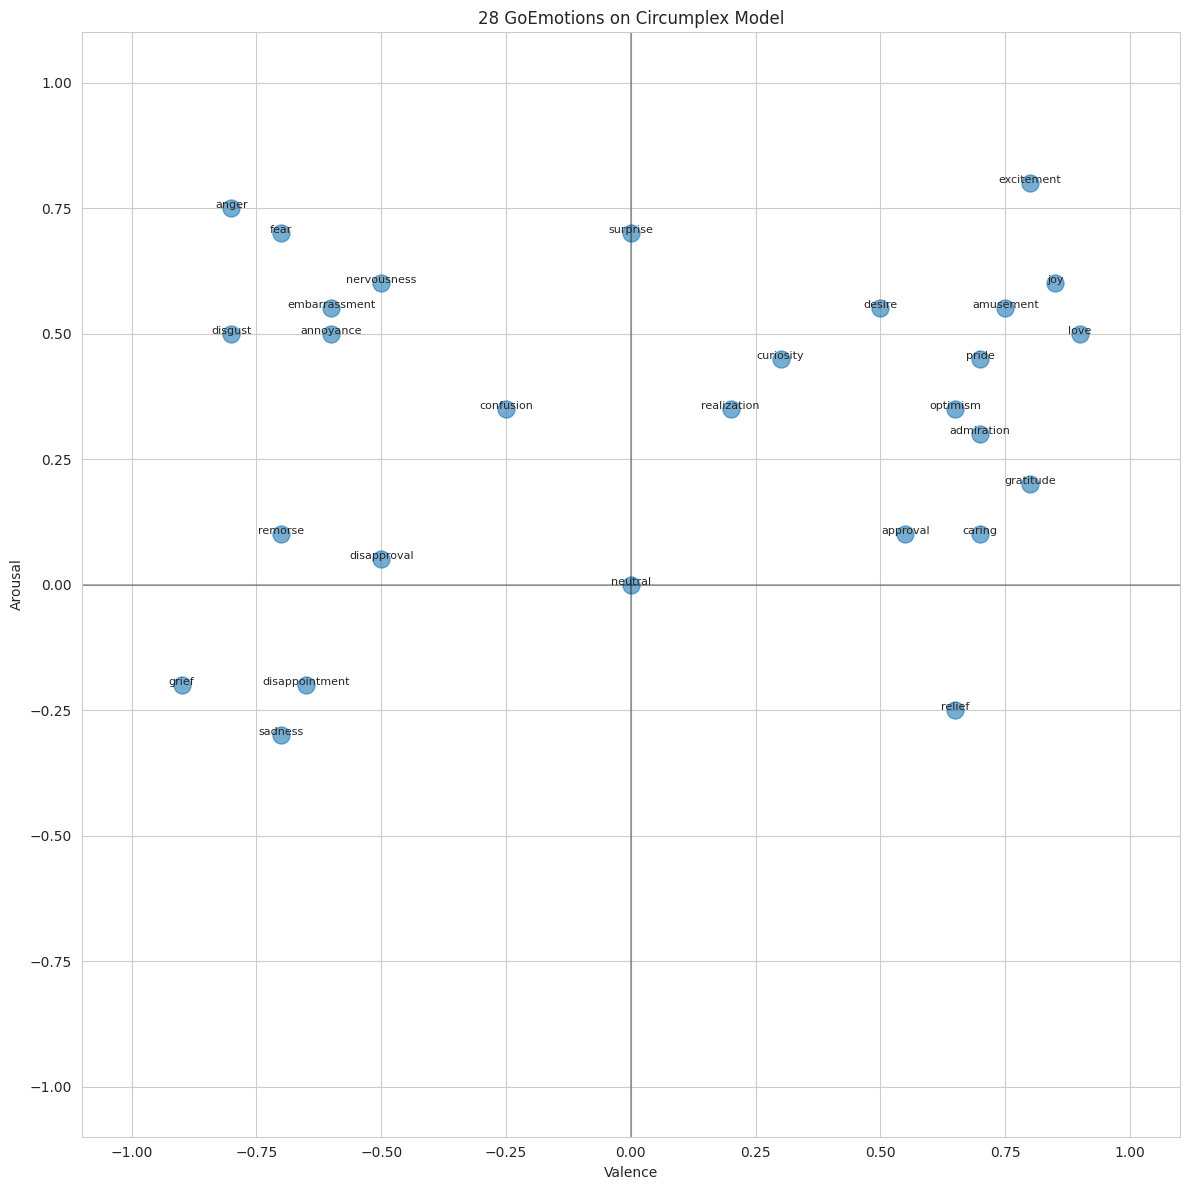

Saved: emotion_positions.png


In [4]:
# Visualization 1: Emotion positions on circumplex
fig, ax = plt.subplots(figsize=(12, 12))

emotions = list(EMOTION_MAPPING.keys())
valences = [EMOTION_MAPPING[e]['valence'] for e in emotions]
arousals = [EMOTION_MAPPING[e]['arousal'] for e in emotions]

ax.scatter(valences, arousals, s=150, alpha=0.6)
for i, emo in enumerate(emotions):
    ax.annotate(emo, (valences[i], arousals[i]), fontsize=8, ha='center')

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('28 GoEmotions on Circumplex Model')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'emotion_positions.png', dpi=200)
plt.show()

print(f"Saved: emotion_positions.png")

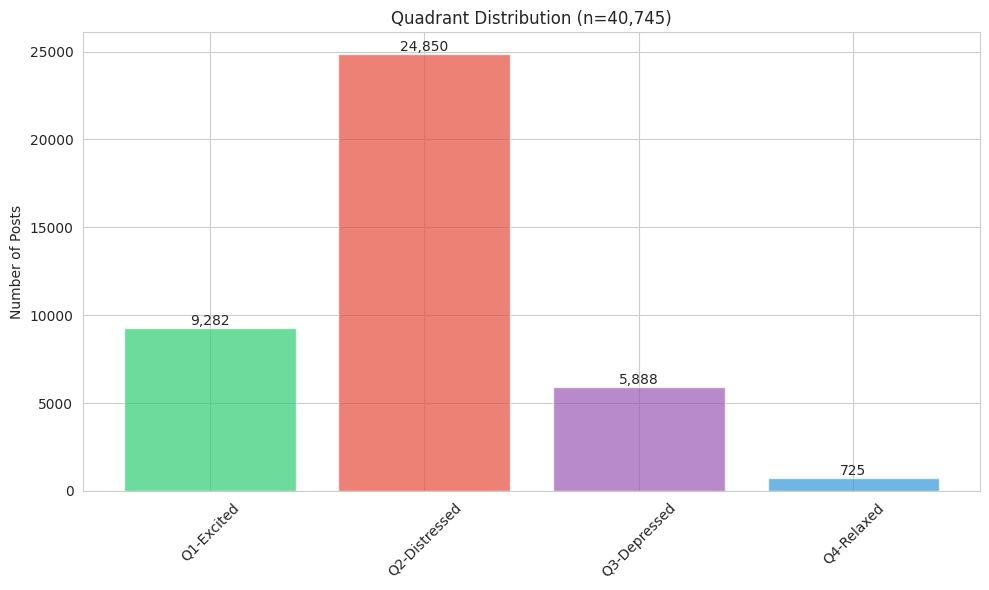

Saved: quadrant_distribution.png

Counts:
quadrant
Q1-Excited        9282
Q2-Distressed    24850
Q3-Depressed      5888
Q4-Relaxed         725
Name: count, dtype: int64


In [5]:
# Visualization 2: Quadrant distribution
fig, ax = plt.subplots(figsize=(10, 6))

counts = df['quadrant'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c', '#9b59b6', '#3498db']
ax.bar(range(len(counts)), counts.values, color=colors, alpha=0.7)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45)
ax.set_ylabel('Number of Posts')
ax.set_title(f'Quadrant Distribution (n={len(df):,})')

for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'quadrant_distribution.png', dpi=200)
plt.show()

print(f"Saved: quadrant_distribution.png")
print("\nCounts:")
print(counts)

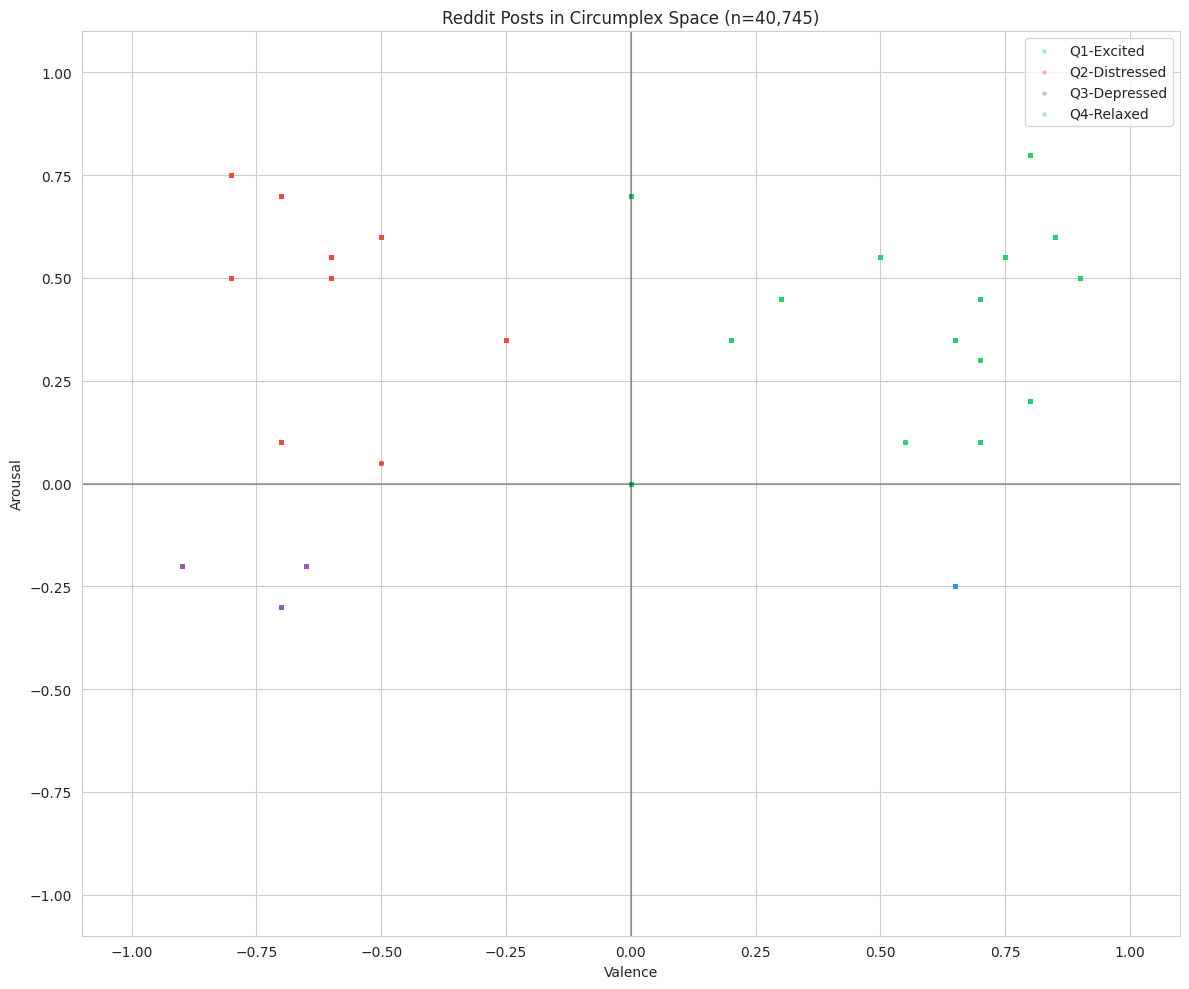

Saved: post_scatter.png


In [6]:
# Visualization 3: Post scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

quad_colors = {
    'Q1-Excited': '#2ecc71',
    'Q2-Distressed': '#e74c3c',
    'Q3-Depressed': '#9b59b6',
    'Q4-Relaxed': '#3498db'
}

for quad, color in quad_colors.items():
    mask = df['quadrant'] == quad
    ax.scatter(df[mask]['valence'], df[mask]['arousal'],
               s=5, alpha=0.3, c=color, label=quad)

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title(f'Reddit Posts in Circumplex Space (n={len(df):,})')
ax.legend()
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'post_scatter.png', dpi=200)
plt.show()

print(f"Saved: post_scatter.png")

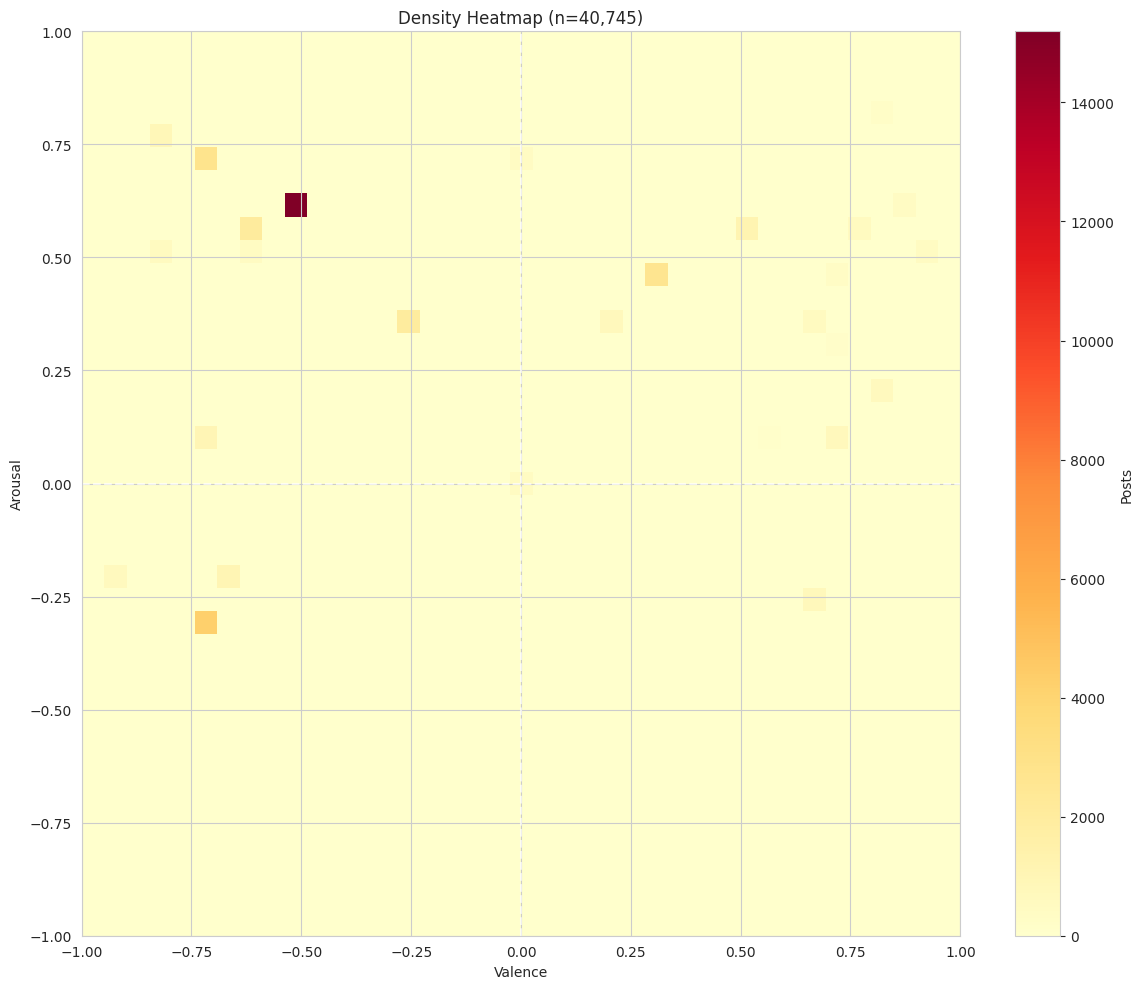

Saved: density_heatmap.png


In [7]:
# Visualization 4: Density heatmap
fig, ax = plt.subplots(figsize=(12, 10))

heatmap, xedges, yedges = np.histogram2d(
    df['valence'], df['arousal'],
    bins=[np.linspace(-1, 1, 40), np.linspace(-1, 1, 40)]
)

im = ax.imshow(heatmap.T, origin='lower', extent=[-1, 1, -1, 1],
               cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Posts')

ax.axhline(y=0, color='white', linestyle='--', alpha=0.7)
ax.axvline(x=0, color='white', linestyle='--', alpha=0.7)
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title(f'Density Heatmap (n={len(df):,})')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'density_heatmap.png', dpi=200)
plt.show()

print(f"Saved: density_heatmap.png")

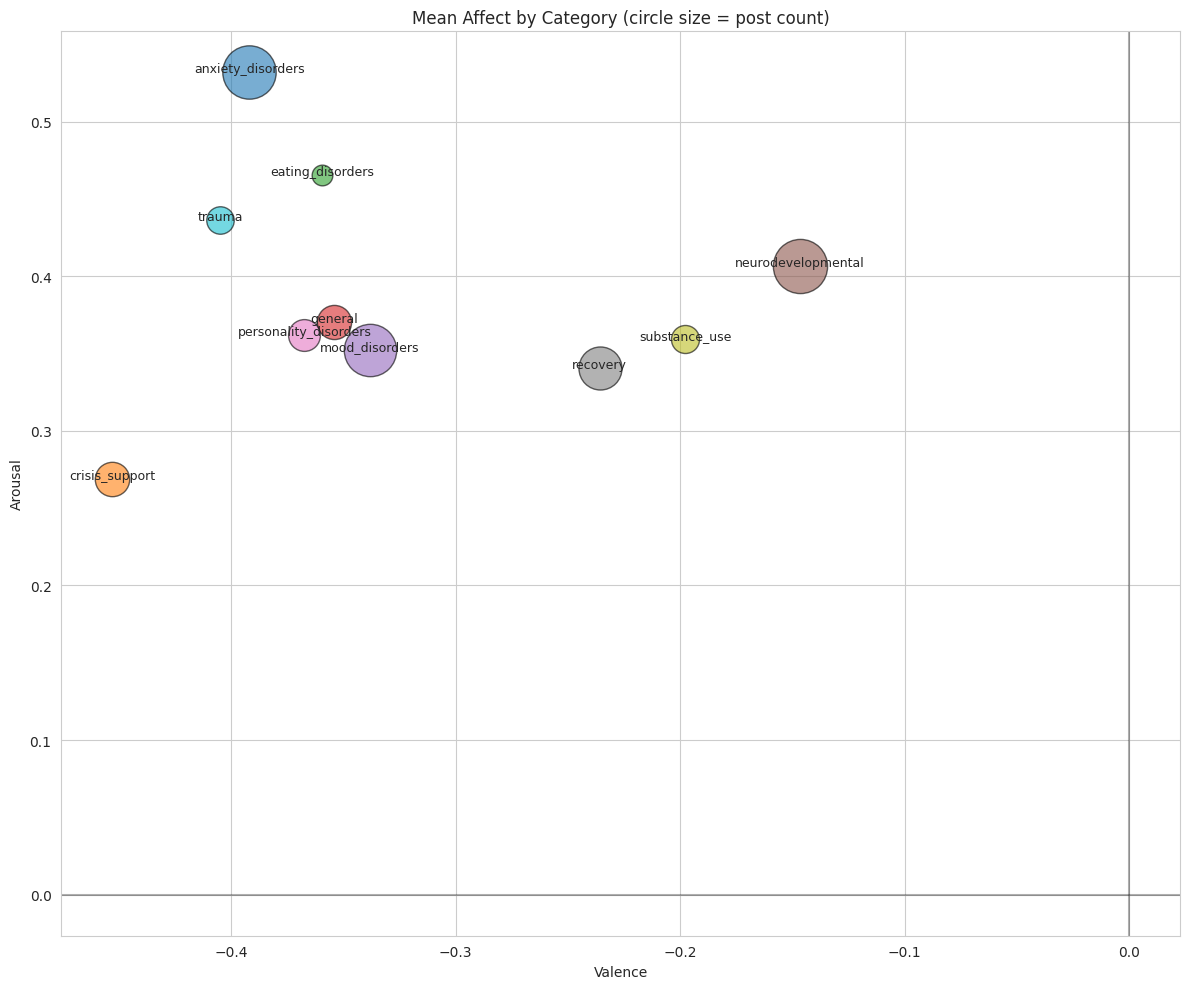

Saved: category_comparison.png

Mean valence/arousal by category:
                       valence  arousal
category                               
anxiety_disorders       -0.392    0.532
crisis_support          -0.453    0.269
eating_disorders        -0.359    0.465
general                 -0.354    0.370
mood_disorders          -0.338    0.352
neurodevelopmental      -0.147    0.407
personality_disorders   -0.367    0.362
recovery                -0.236    0.340
substance_use           -0.198    0.360
trauma                  -0.405    0.437


In [8]:
# Visualization 5: Category comparison
fig, ax = plt.subplots(figsize=(12, 10))

cat_means = df.groupby('category')[['valence', 'arousal']].mean()
cat_counts = df['category'].value_counts()

for cat in cat_means.index:
    v = cat_means.loc[cat, 'valence']
    a = cat_means.loc[cat, 'arousal']
    n = cat_counts[cat]
    ax.scatter(v, a, s=n/5, alpha=0.6, edgecolors='black')
    ax.annotate(cat, (v, a), fontsize=9, ha='center')

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Mean Affect by Category (circle size = post count)')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'category_comparison.png', dpi=200)
plt.show()

print(f"Saved: category_comparison.png")
print("\nMean valence/arousal by category:")
print(cat_means.round(3))

In [9]:
# Summary statistics
print("="*50)
print("VALIDATION SUMMARY")
print("="*50)
print(f"Total posts: {len(df):,}")
print(f"\nValence: mean={df['valence'].mean():.3f}, std={df['valence'].std():.3f}")
print(f"Arousal: mean={df['arousal'].mean():.3f}, std={df['arousal'].std():.3f}")
print(f"\nQuadrant distribution:")
for quad, count in df['quadrant'].value_counts().sort_index().items():
    pct = (count / len(df)) * 100
    print(f"  {quad}: {count:,} ({pct:.1f}%)")
print(f"\n✓ Visualizations saved to: {VIZ_DIR}")

VALIDATION SUMMARY
Total posts: 40,745

Valence: mean=-0.309, std=0.492
Arousal: mean=0.397, std=0.328

Quadrant distribution:
  Q1-Excited: 9,282 (22.8%)
  Q2-Distressed: 24,850 (61.0%)
  Q3-Depressed: 5,888 (14.5%)
  Q4-Relaxed: 725 (1.8%)

✓ Visualizations saved to: /content/drive/MyDrive/mental_health_research_V2/results/reddit_inference/visualizations
